<a href="https://colab.research.google.com/github/swayamsharma1346-maker/AI_Driven_Student_Performance_Prediction_System/blob/main/Ai_Driven_Student_Performance_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


In [25]:
np.random.seed(42)
n = 2500

student_data = pd.DataFrame({
    "Student_ID": [f"STU{10000+i}" for i in range(n)],
    "Age": np.random.randint(17, 25, n),
    "Gender": np.random.choice(["Male", "Female", "Other"], n, p=[0.49, 0.49, 0.02]),
    "Study_Hours_Per_Day": np.clip(np.random.normal(3.5, 1.5, n), 0.5, 10).round(1),
    "Attendance_Percentage": np.clip(np.random.normal(78, 12, n), 40, 100).round(1),
    "Previous_Semester_Score": np.clip(np.random.normal(68, 14, n), 20, 100).round(1),
    "Assignment_Average": np.clip(np.random.normal(72, 13, n), 20, 100).round(1),
    "Internal_Test_Average": np.clip(np.random.normal(69, 15, n), 20, 100).round(1),
    "Sleep_Hours": np.clip(np.random.normal(7, 1.2, n), 4, 10).round(1),
    "Class_Participation_Percentage": np.clip(np.random.normal(70, 18, n), 10, 100).round(1),
    "Extracurricular_Hours_Per_Week": np.clip(np.random.normal(5, 3, n), 0, 20).round(1),
    "Internet_Study_Hours_Per_Day": np.clip(np.random.normal(2.5, 1.3, n), 0, 8).round(1),
    "Family_Support": np.random.choice(["Low", "Medium", "High"], n, p=[0.15, 0.50, 0.35]),
    "Learning_Mode": np.random.choice(["Online", "Offline", "Hybrid"], n, p=[0.25, 0.50, 0.25]),
    "Academic_Background": np.random.choice(["Science", "Commerce", "Arts"], n, p=[0.45, 0.35, 0.20]),
    "Financial_Stress": np.random.choice(["Low", "Medium", "High"], n, p=[0.50, 0.35, 0.15]),
})

# Create a meaningful performance score from academic/behavioral variables.
support_score = student_data["Family_Support"].map({"Low": -4, "Medium": 0, "High": 4})
stress_score = student_data["Financial_Stress"].map({"Low": 3, "Medium": 0, "High": -4})
mode_score = student_data["Learning_Mode"].map({"Online": -1, "Offline": 1, "Hybrid": 2})

performance_score = (
    0.22 * student_data["Previous_Semester_Score"] +
    0.18 * student_data["Assignment_Average"] +
    0.20 * student_data["Internal_Test_Average"] +
    0.15 * student_data["Attendance_Percentage"] +
    2.5 * student_data["Study_Hours_Per_Day"] +
    0.05 * student_data["Class_Participation_Percentage"] +
    0.8 * student_data["Sleep_Hours"] +
    0.3 * student_data["Internet_Study_Hours_Per_Day"] +
    support_score + stress_score + mode_score +
    np.random.normal(0, 7, n)
)

student_data["Final_Score"] = np.clip(performance_score, 0, 100).round(1)

# Convert score to a 3-class prediction target.
student_data["Performance_Level"] = pd.cut(
    student_data["Final_Score"],
    bins=[-np.inf, 55, 75, np.inf],
    labels=[0, 1, 2]
).astype(int)

student_data.to_csv("student_performance_dataset.csv", index=False)

df = pd.read_csv("student_performance_dataset.csv")
print("Dataset created successfully!")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset created successfully!
Dataset Shape: (2500, 18)


,Student_ID,Age,Gender,Study_Hours_Per_Day,Attendance_Percentage,Previous_Semester_Score,Assignment_Average,Internal_Test_Average,Sleep_Hours,Class_Participation_Percentage,Extracurricular_Hours_Per_Week,Internet_Study_Hours_Per_Day,Family_Support,Learning_Mode,Academic_Background,Financial_Stress,Final_Score,Performance_Level
0,STU10000,23,Female,5.2,65.6,69.3,66.4,84.4,6.1,84.4,1.6,2.0,Low,Online,Science,Low,68.6,1
1,STU10001,20,Male,1.8,75.6,62.7,93.8,49.9,7.6,42.3,2.4,0.0,Medium,Online,Commerce,Medium,61.7,1
2,STU10002,21,Male,2.3,77.6,59.2,55.5,85.4,5.1,92.1,5.6,3.4,Medium,Offline,Arts,Medium,72.1,1
3,STU10003,23,Male,2.6,85.9,90.9,59.1,84.7,7.9,58.5,0.0,2.3,High,Offline,Science,Medium,88.1,2
4,STU10004,19,Female,2.7,91.1,57.1,63.1,54.9,7.7,48.1,6.3,2.1,High,Offline,Arts,Low,70.6,1


In [26]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Dataset Shape: (2500, 18)

Column Names:
['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day', 'Attendance_Percentage', 'Previous_Semester_Score', 'Assignment_Average', 'Internal_Test_Average', 'Sleep_Hours', 'Class_Participation_Percentage', 'Extracurricular_Hours_Per_Week', 'Internet_Study_Hours_Per_Day', 'Family_Support', 'Learning_Mode', 'Academic_Background', 'Financial_Stress', 'Final_Score', 'Performance_Level']

Data Types:
Student_ID                         object
Age                                 int64
Gender                             object
Study_Hours_Per_Day               float64
Attendance_Percentage             float64
Previous_Semester_Score           float64
Assignment_Average                float64
Internal_Test_Average             float64
Sleep_Hours                       float64
Class_Participation_Percentage    float64
Extracurricular_Hours_Per_Week    float64
Internet_Study_Hours_Per_Day      float64
Family_Support                     object
Learning_Mode    

In [27]:
print("========== DATA QUALITY REPORT ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nPerformance Level Distribution:")
print(df["Performance_Level"].value_counts().sort_index())

print("\nPerformance Level Percentage:")
print(
    df["Performance_Level"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

========== DATA QUALITY REPORT ==========
Rows: 2500
Columns: 18

Missing values:
0

Duplicate rows: 0

Performance Level Distribution:
Performance_Level
0      84
1    1278
2    1138
Name: count, dtype: int64

Performance Level Percentage:
Performance_Level
0     3.36
1    51.12
2    45.52
Name: proportion, dtype: float64


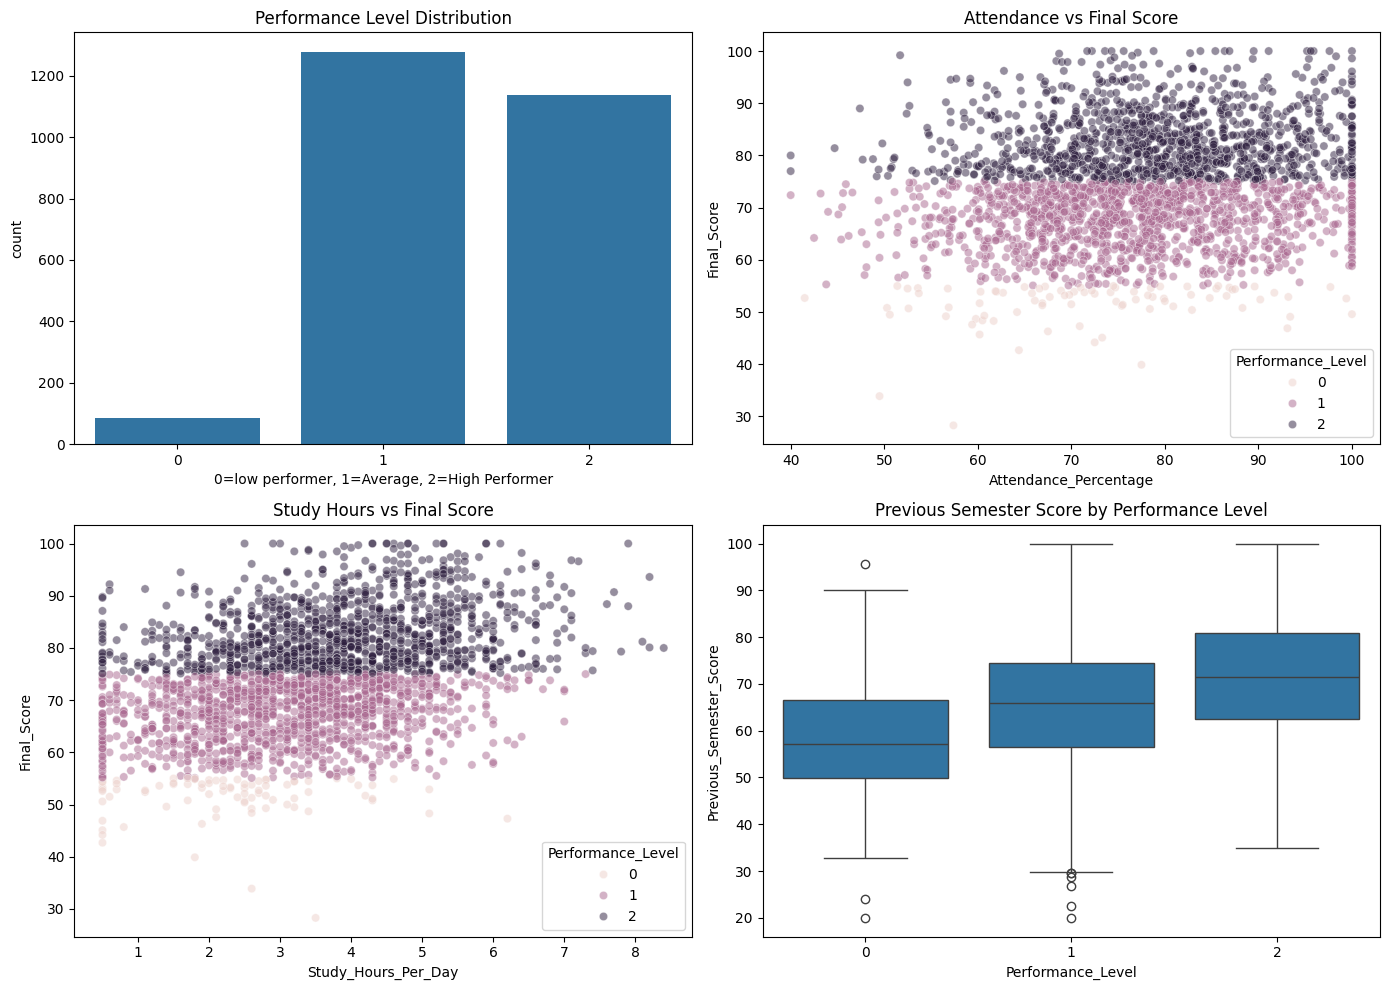

In [28]:
ig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Performance_Level", ax=axes[0, 0])
axes[0, 0].set_title("Performance Level Distribution")
axes[0, 0].set_xlabel("0=low performer, 1=Average, 2=High Performer")

sns.scatterplot(
    data=df, x="Attendance_Percentage", y="Final_Score",
    hue="Performance_Level", alpha=0.5, ax=axes[0, 1]
)
axes[0, 1].set_title("Attendance vs Final Score")

sns.scatterplot(
    data=df, x="Study_Hours_Per_Day", y="Final_Score",
    hue="Performance_Level", alpha=0.5, ax=axes[1, 0]
)
axes[1, 0].set_title("Study Hours vs Final Score")

sns.boxplot(
    data=df, x="Performance_Level", y="Previous_Semester_Score",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Previous Semester Score by Performance Level")

plt.tight_layout()
plt.show()

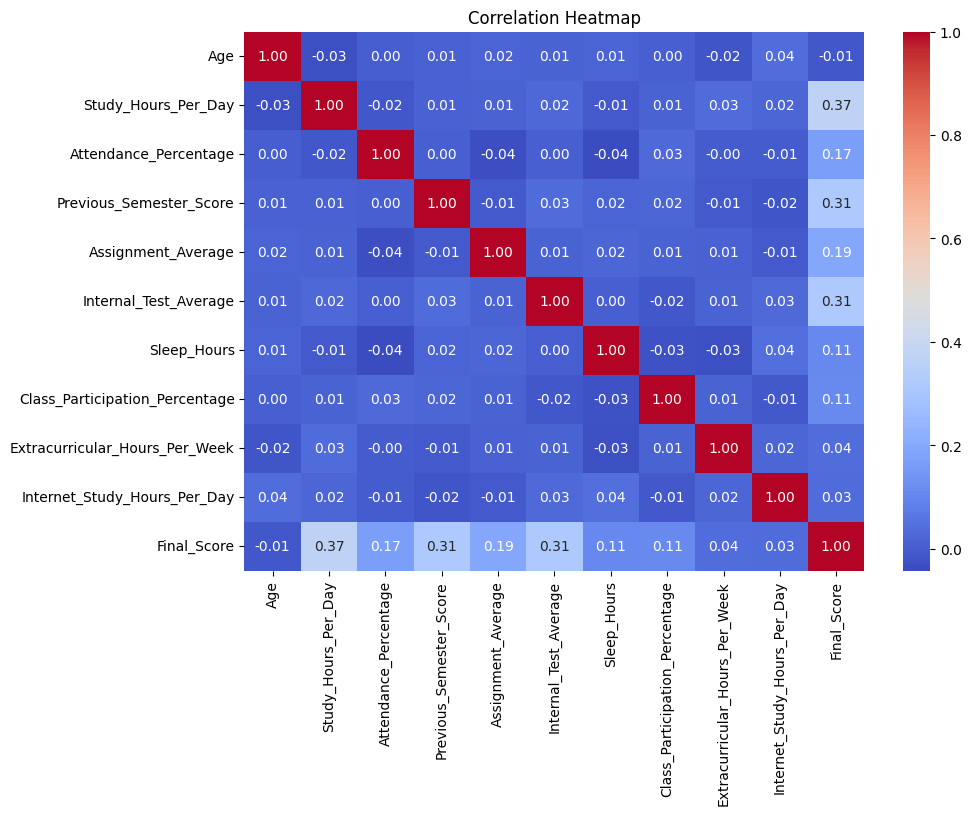

In [29]:
plt.figure(figsize=(10, 7))
numeric_cols = [
    "Age", "Study_Hours_Per_Day", "Attendance_Percentage",
    "Previous_Semester_Score", "Assignment_Average",
    "Internal_Test_Average", "Sleep_Hours",
    "Class_Participation_Percentage", "Extracurricular_Hours_Per_Week",
    "Internet_Study_Hours_Per_Day", "Final_Score"
]
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [30]:
df["Academic_Average"] = (
    df["Previous_Semester_Score"] +
    df["Assignment_Average"] +
    df["Internal_Test_Average"]
) / 3

df["Study_Efficiency"] = (
    df["Study_Hours_Per_Day"] * df["Attendance_Percentage"] / 100
)

df["Engagement_Score"] = (
    0.6 * df["Class_Participation_Percentage"] +
    0.4 * df["Attendance_Percentage"]
)

df["Support_Index"] = (
    df["Family_Support"].map({"Low": 0, "Medium": 1, "High": 2}) +
    df["Financial_Stress"].map({"High": 0, "Medium": 1, "Low": 2})
)

print("Feature engineering completed.")
display(df[[
    "Academic_Average", "Study_Efficiency",
    "Engagement_Score", "Support_Index", "Performance_Level"
]].head())

Feature engineering completed.


,Academic_Average,Study_Efficiency,Engagement_Score,Support_Index,Performance_Level
0,73.366667,3.4112,76.88,2,1
1,68.800000,1.3608,55.62,2,1
2,66.700000,1.7848,86.30,2,1
3,78.233333,2.2334,69.46,3,2
4,58.366667,2.4597,65.30,4,1


In [31]:
target = "Performance_Level"

features = [
    "Age", "Gender", "Study_Hours_Per_Day", "Attendance_Percentage",
    "Previous_Semester_Score", "Assignment_Average",
    "Internal_Test_Average", "Sleep_Hours",
    "Class_Participation_Percentage", "Extracurricular_Hours_Per_Week",
    "Internet_Study_Hours_Per_Day", "Family_Support", "Learning_Mode",
    "Academic_Background", "Financial_Stress",
    "Academic_Average", "Study_Efficiency",
    "Engagement_Score", "Support_Index"
]

X = df[features]
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2500, 19)
Target Shape: (2500,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2000
Testing rows: 500


In [33]:
numeric_features = [
    "Age", "Study_Hours_Per_Day", "Attendance_Percentage",
    "Previous_Semester_Score", "Assignment_Average",
    "Internal_Test_Average", "Sleep_Hours",
    "Class_Participation_Percentage", "Extracurricular_Hours_Per_Week",
    "Internet_Study_Hours_Per_Day", "Academic_Average",
    "Study_Efficiency", "Engagement_Score", "Support_Index"
]

categorical_features = [
    "Gender", "Family_Support", "Learning_Mode",
    "Academic_Background", "Financial_Stress"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12,
        min_samples_leaf=3, random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1_Score": f1_score(y_test, pred, average="weighted", zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("F1_Score", ascending=False)

print("Model training completed successfully!")
display(results_df.round(4))

Model training completed successfully!


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.738,0.7261,0.738,0.7300,0.8421
2,Random Forest,0.726,0.7015,0.726,0.7134,0.8186
1,Decision Tree,0.624,0.6207,0.624,0.6204,0.7015


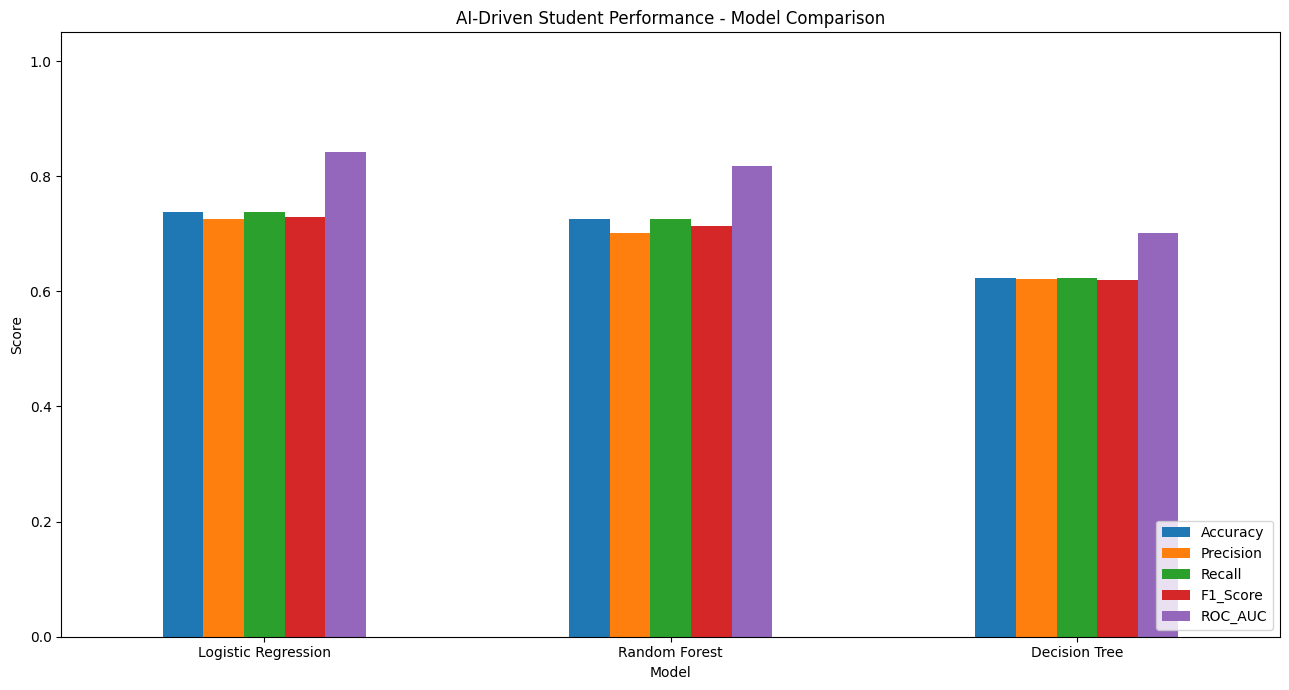

Best Model: Logistic Regression


In [35]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar", figsize=(13, 7)
)
plt.title("AI-Driven Student Performance - Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

========== BEST MODEL EVALUATION ==========
Model: Logistic Regression

Classification Report:
                precision    recall  f1-score   support

  low perfomer       0.20      0.06      0.09        17
       Average       0.73      0.79      0.75       256
High Performer       0.77      0.74      0.75       227

      accuracy                           0.74       500
     macro avg       0.56      0.53      0.53       500
  weighted avg       0.73      0.74      0.73       500



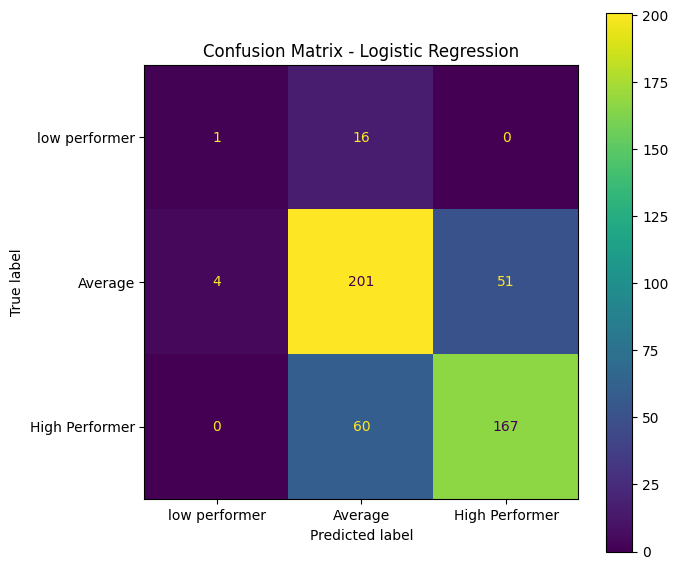

In [36]:
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)

print("========== BEST MODEL EVALUATION ==========")
print("Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(
    y_test, best_pred,
    target_names=["low perfomer", "Average", "High Performer"],
    zero_division=0
))

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["low performer", "Average", "High Performer"]
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [37]:
new_student = pd.DataFrame([{
    "Age": 21,
    "Gender": "Male",
    "Study_Hours_Per_Day": 5.0,
    "Attendance_Percentage": 88.0,
    "Previous_Semester_Score": 78.0,
    "Assignment_Average": 82.0,
    "Internal_Test_Average": 80.0,
    "Sleep_Hours": 7.0,
    "Class_Participation_Percentage": 85.0,
    "Extracurricular_Hours_Per_Week": 4.0,
    "Internet_Study_Hours_Per_Day": 3.0,
    "Family_Support": "High",
    "Learning_Mode": "Hybrid",
    "Academic_Background": "Commerce",
    "Financial_Stress": "Low"
}])

new_student["Academic_Average"] = (
    new_student["Previous_Semester_Score"] +
    new_student["Assignment_Average"] +
    new_student["Internal_Test_Average"]
) / 3

new_student["Study_Efficiency"] = (
    new_student["Study_Hours_Per_Day"] *
    new_student["Attendance_Percentage"] / 100
)

new_student["Engagement_Score"] = (
    0.6 * new_student["Class_Participation_Percentage"] +
    0.4 * new_student["Attendance_Percentage"]
)

new_student["Support_Index"] = (
    new_student["Family_Support"].map({"Low": 0, "Medium": 1, "High": 2}) +
    new_student["Financial_Stress"].map({"High": 0, "Medium": 1, "Low": 2})
)

prediction = int(best_model.predict(new_student[features])[0])
probabilities = best_model.predict_proba(new_student[features])[0]

label_map = {
    0: "low perfomer",
    1: "Average",
    2: "High Performer"
}

print("Predicted Performance Level:", label_map[prediction])
print("\nPrediction Probabilities:")
for class_id, probability in zip(best_model.classes_, probabilities):
    print(f"{label_map[int(class_id)]}: {probability:.2%}")

Predicted Performance Level: High Performer

Prediction Probabilities:
low perfomer: 0.00%
Average: 1.84%
High Performer: 98.16%


In [38]:
model_file = "student_performance_prediction_model.joblib"
joblib.dump(best_model, model_file)

print(f"Model saved successfully: {model_file}")

# Example of loading the saved model
loaded_model = joblib.load(model_file)
print("Saved model loaded successfully!")

Model saved successfully: student_performance_prediction_model.joblib
Saved model loaded successfully!
